In [1]:
from google.colab import drive
drive.mount('/content/drive') # Mount Google Drive

Mounted at /content/drive


In [2]:
import os
import json
import numpy as np
import pandas as pd
from PIL import Image
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# library versions
versions = {
    "Python": os.sys.version,
    "torch": torch.__version__,
}

for lib, ver in versions.items():
    print(f"{lib}: {ver}")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
torch: 2.11.0+cu128


## Also have to try with multiple seeds

In [ ]:
seeds = [7, 10, 42, 56, 100]

In [ ]:
# seeting seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Data Loading and EDA

In [ ]:
IMAGE_DIR = "/content/drive/MyDrive/CPS Internship/shared task/Train/train_images"
TRAIN_EXCEL_FILE = "/content/drive/MyDrive/CPS Internship/shared task/Train/train_labels.xlsx"

df = pd.read_excel(TRAIN_EXCEL_FILE)

print("Shape of the dataframe is : ", df.shape)
df.head()

Shape of the dataframe is :  (969, 4)


,Image_id,Text,Level1,Level2
0,0,• கர்நாடகாவில் ரஜினியின் காலா படம் வெளியா முதல...,Troll/Oppose,Troll/Oppose Against Person
1,1,Thalapathy Vijay Thiruchchi Varugai...\nThiruc...,Support/Praise,Support for person
2,2,"\n\n""அண்ண சொல்லுங்க.\n#GET OU MODI\n#GET OUT S...",Troll/Oppose,Troll/Oppose Against Party
3,3,சீமான் கவுண்டமணி மரண கலாய்\nதேங்காய அங்கேயே வை...,Troll/Oppose,Troll/Oppose Against Person
4,4,TOI - LINE OF NO CONTROL \nKAMAL HAASAN START...,Support/Praise,Support for party


In [ ]:
files_in_dir = os.listdir(IMAGE_DIR)
stem_to_file = {}

for fname in files_in_dir:
    stem, _ = os.path.splitext(fname)
    stem_to_file[stem] = fname

def resolve_image_path(image_id):
    stem = str(image_id).zfill(3)   # 0 -> "000", 1 -> "001", etc.
    if stem in stem_to_file:
        return stem_to_file[stem]
    return None

df['image_path'] = df['Image_id'].apply(resolve_image_path)

df.head()

,Image_id,Text,Level1,Level2,image_path
0,0,• கர்நாடகாவில் ரஜினியின் காலா படம் வெளியா முதல...,Troll/Oppose,Troll/Oppose Against Person,000.jpg
1,1,Thalapathy Vijay Thiruchchi Varugai...\nThiruc...,Support/Praise,Support for person,001.jpg
2,2,"\n\n""அண்ண சொல்லுங்க.\n#GET OU MODI\n#GET OUT S...",Troll/Oppose,Troll/Oppose Against Party,002.jpg
3,3,சீமான் கவுண்டமணி மரண கலாய்\nதேங்காய அங்கேயே வை...,Troll/Oppose,Troll/Oppose Against Person,003.jpg
4,4,TOI - LINE OF NO CONTROL \nKAMAL HAASAN START...,Support/Praise,Support for party,004.jpg


In [ ]:
# check for null images in image_path column

print(f"Count of null images are : {df['image_path'].isnull().sum()}")

Count of null images are : 0


In [ ]:
# Label counts for each level

print(f"Level1 label counts: \n{df['Level1'].value_counts()}")

print(f"\nLevel2 label counts: \n{df['Level2'].value_counts()}")

Level1 label counts: 
Level1
Troll/Oppose      692
Support/Praise    277
Name: count, dtype: int64

Level2 label counts: 
Level2
Troll/Oppose Against Person    545
Support for person             179
Troll/Oppose Against Party     147
Support for party               98
Name: count, dtype: int64


## Initial distribution of the data classes at leavel 1 and level 2

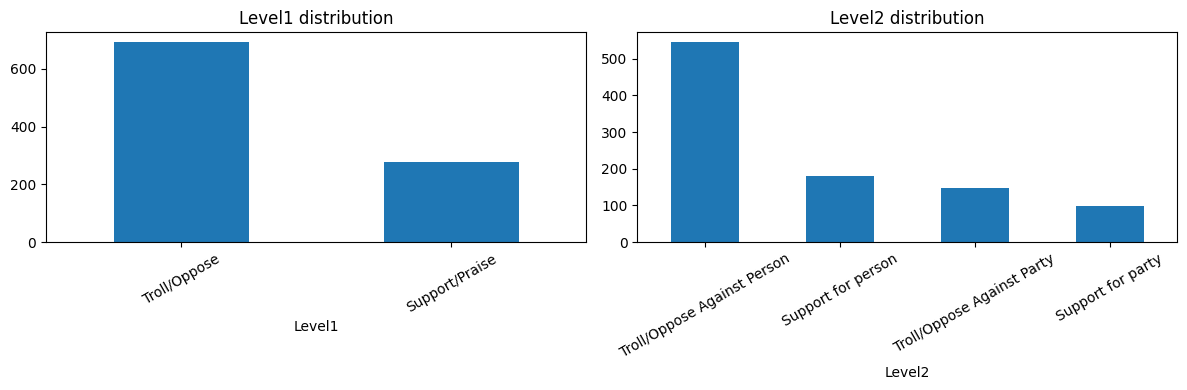

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Level1'].value_counts().plot(kind='bar', ax=axes[0], title='Level1 distribution')
df['Level2'].value_counts().plot(kind='bar', ax=axes[1], title='Level2 distribution')
axes[0].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### Train and validation splitting: holding 90% instances for training and remaining 10% for validation

In [ ]:
train_df, val_df = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df['Level1']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", train_df.shape, " Val:", val_df.shape)

Train: (872, 5)  Val: (97, 5)


### Train df data distribution

Level1 label counts: 
Level1
Troll/Oppose      623
Support/Praise    249
Name: count, dtype: int64

Level2 label counts: 
Level2
Troll/Oppose Against Person    494
Support for person             158
Troll/Oppose Against Party     129
Support for party               91
Name: count, dtype: int64


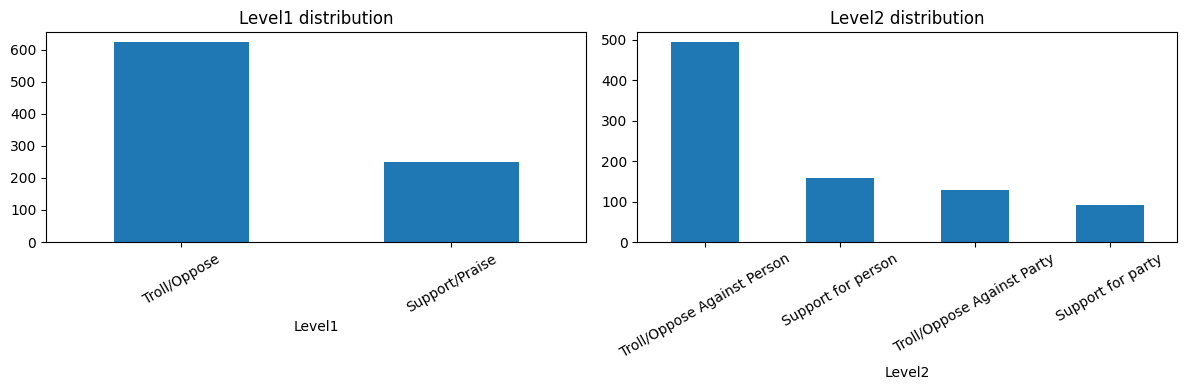

In [ ]:
print(f"Level1 label counts: \n{train_df['Level1'].value_counts()}")

print(f"\nLevel2 label counts: \n{train_df['Level2'].value_counts()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['Level1'].value_counts().plot(kind='bar', ax=axes[0], title='Level1 distribution')
train_df['Level2'].value_counts().plot(kind='bar', ax=axes[1], title='Level2 distribution')
axes[0].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Test df data distribution

Level1 label counts: 
Level1
Troll/Oppose      69
Support/Praise    28
Name: count, dtype: int64

Level2 label counts: 
Level2
Troll/Oppose Against Person    51
Support for person             21
Troll/Oppose Against Party     18
Support for party               7
Name: count, dtype: int64


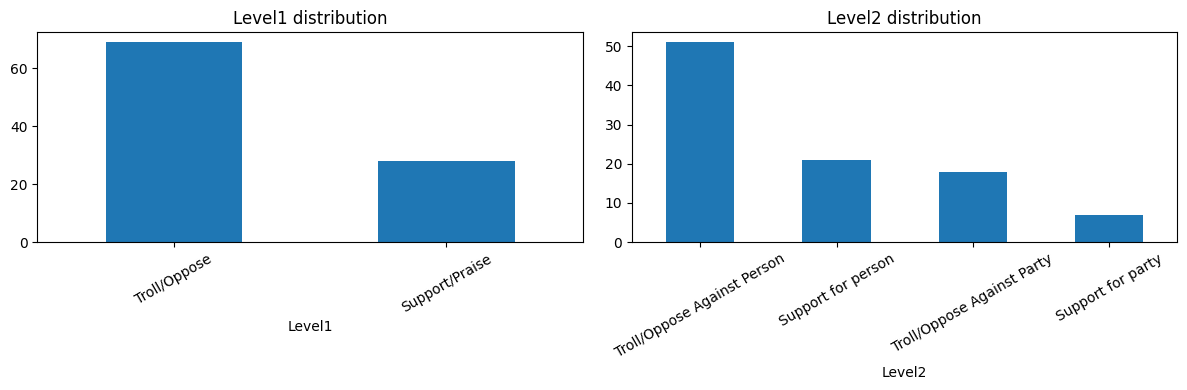

In [ ]:
print(f"Level1 label counts: \n{val_df['Level1'].value_counts()}")

print(f"\nLevel2 label counts: \n{val_df['Level2'].value_counts()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
val_df['Level1'].value_counts().plot(kind='bar', ax=axes[0], title='Level1 distribution')
val_df['Level2'].value_counts().plot(kind='bar', ax=axes[1], title='Level2 distribution')
axes[0].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

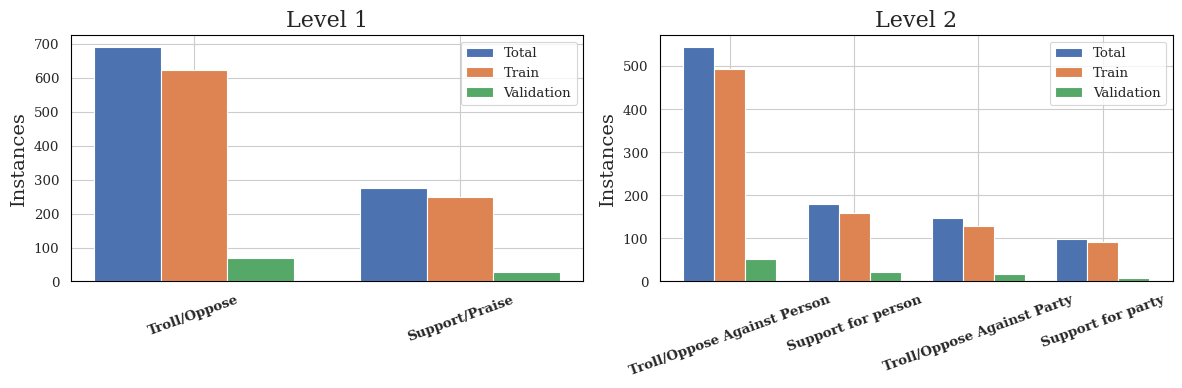

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Level1 comparison
total_counts1 = df['Level1'].value_counts()
train_counts1 = train_df['Level1'].value_counts()
val_counts1 = val_df['Level1'].value_counts()
labels1 = total_counts1.index

labels1 = total_counts1.index
x = np.arange(len(labels1))

axes[0].bar(x - 0.25, total_counts1, width=0.25, label='Total')
axes[0].bar(x, train_counts1, width=0.25, label='Train')
axes[0].bar(x + 0.25, val_counts1, width=0.25, label='Validation')

axes[0].set_xticks(x)
axes[0].set_ylabel("Instances", fontsize=14)
axes[0].set_xticklabels(labels1, rotation=20, fontweight='bold')
axes[0].set_title("Level 1", fontsize=16)
axes[0].legend()

# Level2 comparison
total_counts2 = df['Level2'].value_counts()
train_counts2 = train_df['Level2'].value_counts()
val_counts2 = val_df['Level2'].value_counts()

labels2 = total_counts2.index
x = np.arange(len(labels2))

axes[1].bar(x - 0.25, total_counts2, width=0.25, label='Total')
axes[1].bar(x, train_counts2, width=0.25, label='Train')
axes[1].bar(x + 0.25, val_counts2, width=0.25, label='Validation')

axes[1].set_xticks(x)
axes[1].set_ylabel("Instances", fontsize=14)
axes[1].set_xticklabels(labels2, rotation=20, fontweight='bold')
axes[1].set_title("Level 2", fontsize=16)
axes[1].legend()

# fig.suptitle('Label Distribution Across Dataset Splits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Export at publication resolution
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

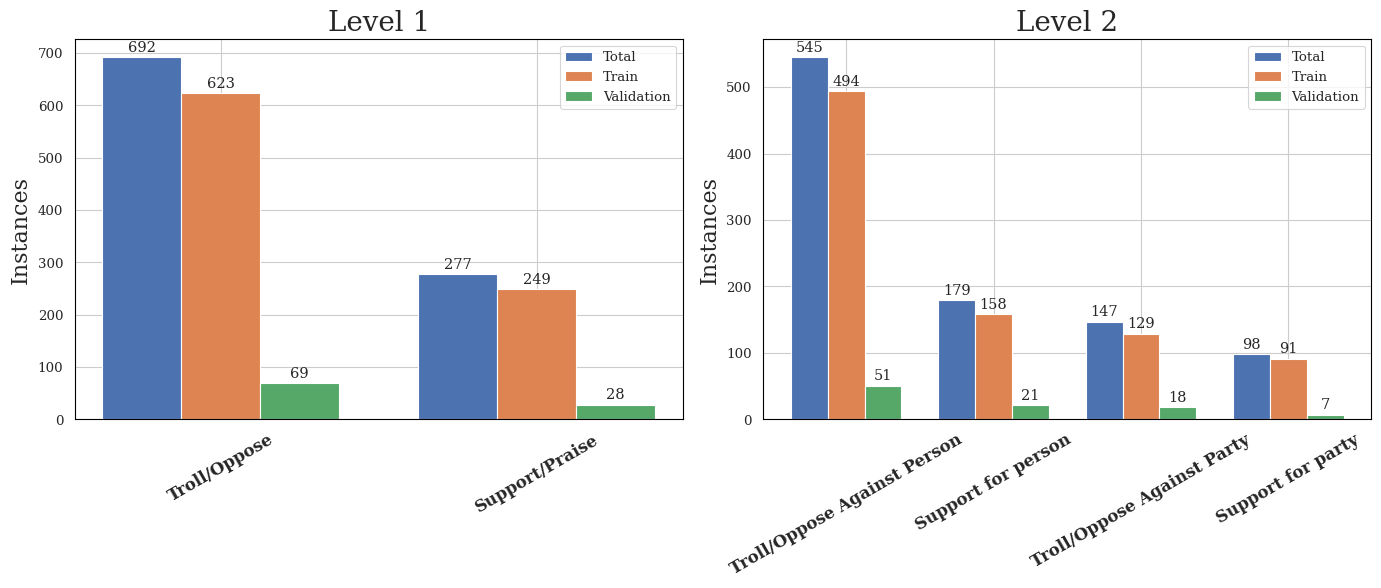

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Level1 comparison ---
total_counts1 = df['Level1'].value_counts()
train_counts1 = train_df['Level1'].value_counts().reindex(total_counts1.index, fill_value=0)
val_counts1   = val_df['Level1'].value_counts().reindex(total_counts1.index, fill_value=0)

labels1 = total_counts1.index
x = np.arange(len(labels1))

bars_total = axes[0].bar(x - 0.25, total_counts1, width=0.25, label='Total')
bars_train = axes[0].bar(x, train_counts1, width=0.25, label='Train')
bars_val   = axes[0].bar(x + 0.25, val_counts1, width=0.25, label='Validation')

axes[0].set_xticks(x)
axes[0].set_ylabel("Instances", fontsize=16)
axes[0].set_xticklabels(labels1, rotation=30, fontweight='bold', fontsize=12)
axes[0].set_title("Level 1", fontsize=20)
axes[0].legend()

# Add labels on bars
axes[0].bar_label(bars_total, padding=2)
axes[0].bar_label(bars_train, padding=2)
axes[0].bar_label(bars_val, padding=2)

# --- Level2 comparison ---
total_counts2 = df['Level2'].value_counts()
train_counts2 = train_df['Level2'].value_counts().reindex(total_counts2.index, fill_value=0)
val_counts2   = val_df['Level2'].value_counts().reindex(total_counts2.index, fill_value=0)

labels2 = total_counts2.index
x = np.arange(len(labels2))

bars_total = axes[1].bar(x - 0.25, total_counts2, width=0.25, label='Total')
bars_train = axes[1].bar(x, train_counts2, width=0.25, label='Train')
bars_val   = axes[1].bar(x + 0.25, val_counts2, width=0.25, label='Validation')

axes[1].set_xticks(x)
axes[1].set_ylabel("Instances", fontsize=16)
axes[1].set_xticklabels(labels2, rotation=30, fontweight='bold', fontsize=12)
axes[1].set_title("Level 2", fontsize=20)
axes[1].legend()

# Add labels on bars
axes[1].bar_label(bars_total, padding=2)
axes[1].bar_label(bars_train, padding=2)
axes[1].bar_label(bars_val, padding=2)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# datasets = [
#     (df, 'Before Split'),
#     (train_df, 'Train'),
#     (val_df, 'Validation')
# ]

# for col, (data, title) in enumerate(datasets):
#     data['Level1'].value_counts().plot(kind='bar', ax=axes[0, col], title=f'Level1 — {title}')
#     data['Level2'].value_counts().plot(kind='bar', ax=axes[1, col], title=f'Level2 — {title}')
#     axes[1, col].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

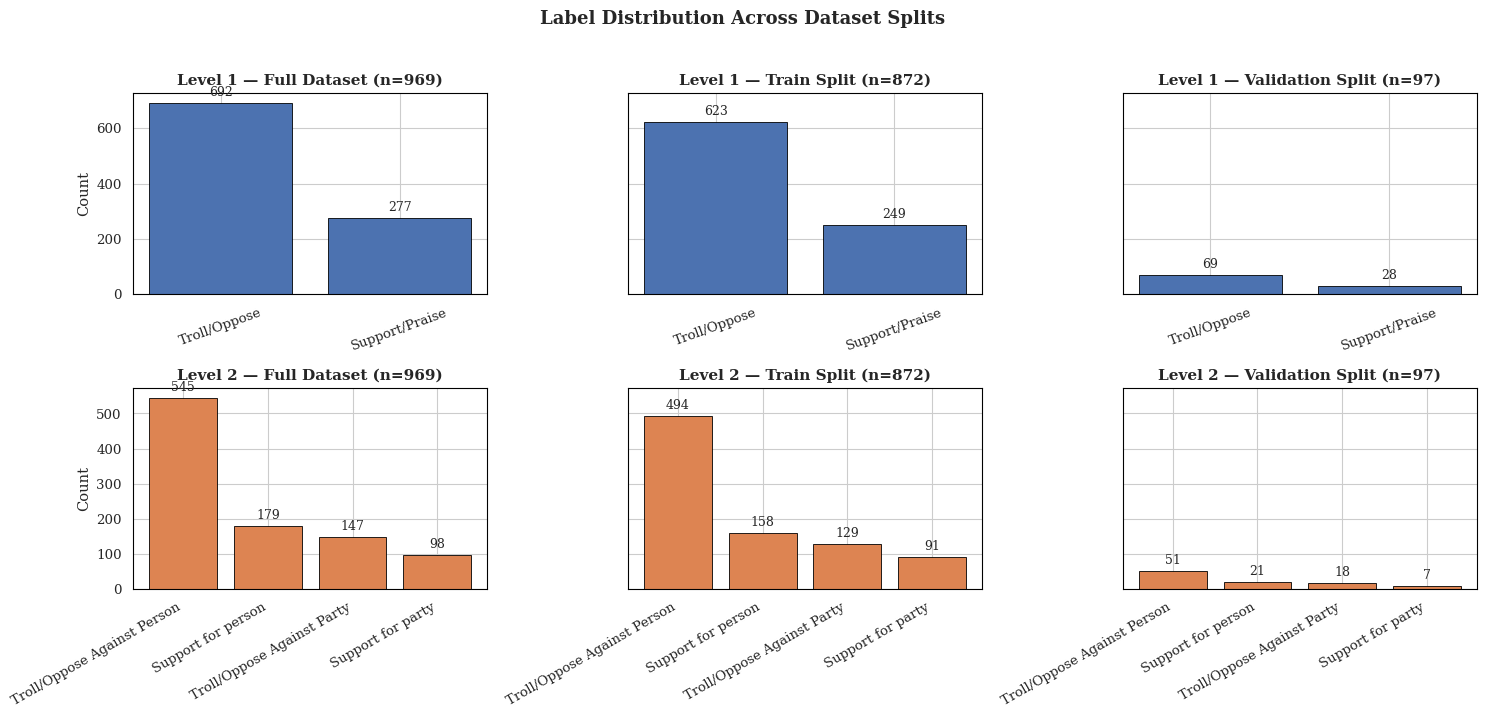

In [ ]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 0.8

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey='row')

datasets = [
    (df, 'Full Dataset (n={})'.format(len(df))),
    (train_df, 'Train Split (n={})'.format(len(train_df))),
    (val_df, 'Validation Split (n={})'.format(len(val_df)))
]

l1_color = "#4C72B0"
l2_color = "#DD8452"

for col, (data, title) in enumerate(datasets):
    # Level 1
    counts_l1 = data['Level1'].value_counts()
    bars1 = axes[0, col].bar(counts_l1.index, counts_l1.values, color=l1_color, edgecolor='black', linewidth=0.6)
    axes[0, col].set_title(f'Level 1 — {title}', fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel('Count' if col == 0 else '')
    axes[0, col].tick_params(axis='x', rotation=20)
    for bar in bars1:
        h = bar.get_height()
        axes[0, col].annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width() / 2, h),
                               xytext=(0, 3), textcoords='offset points',
                               ha='center', va='bottom', fontsize=9)

    # Level 2
    counts_l2 = data['Level2'].value_counts()
    bars2 = axes[1, col].bar(counts_l2.index, counts_l2.values, color=l2_color, edgecolor='black', linewidth=0.6)
    axes[1, col].set_title(f'Level 2 — {title}', fontsize=11, fontweight='bold')
    axes[1, col].set_ylabel('Count' if col == 0 else '')
    axes[1, col].tick_params(axis='x', rotation=30)
    for label in axes[1, col].get_xticklabels():
        label.set_ha('right')
    for bar in bars2:
        h = bar.get_height()
        axes[1, col].annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width() / 2, h),
                               xytext=(0, 3), textcoords='offset points',
                               ha='center', va='bottom', fontsize=9)

fig.suptitle('Label Distribution Across Dataset Splits', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

# Export at publication resolution
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Label encoding the classes for processing

In [ ]:
le1 = LabelEncoder()
le2 = LabelEncoder()

train_df['l1_id'] = le1.fit_transform(train_df['Level1'])
val_df['l1_id']   = le1.transform(val_df['Level1'])

train_df['l2_id'] = le2.fit_transform(train_df['Level2'])
val_df['l2_id']   = le2.transform(val_df['Level2'])

NUM_L1 = len(le1.classes_)
NUM_L2 = len(le2.classes_)
print("Level 1 classes:", list(le1.classes_))
print("Level 2 classes:", list(le2.classes_))

Level 1 classes: ['Support/Praise', 'Troll/Oppose']
Level 2 classes: ['Support for party', 'Support for person', 'Troll/Oppose Against Party', 'Troll/Oppose Against Person']


#### Creating embeddings for image and text

In [ ]:
text_model = SentenceTransformer('BAAI/bge-m3', device=str(device))
img_model = SentenceTransformer('clip-ViT-B-32', device=str(device))

print("BAAI-BGE-M3 text embedding dimension:", text_model.get_sentence_embedding_dimension())
print("CLIP image embedding dimension:", img_model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

BAAI-BGE-M3 text embedding dimension: 1024
CLIP image embedding dimension: 512


/tmp/ipykernel_2139/693888070.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("BAAI-BGE-M3 text embedding dimension:", text_model.get_sentence_embedding_dimension())
/tmp/ipykernel_2139/693888070.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("CLIP image embedding dimension:", img_model.get_sentence_embedding_dimension())


In [ ]:
def get_image_embeddings(paths, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(paths), batch_size)):
        batch_paths = paths[i:i+batch_size]
        imgs = [Image.open(os.path.join(IMAGE_DIR, p)).convert("RGB") for p in batch_paths]
        emb = img_model.encode(imgs, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=False)
        embeddings.append(emb)
    return np.vstack(embeddings)

def get_text_embeddings(texts, batch_size=32):
    return text_model.encode(list(texts), batch_size=batch_size, convert_to_numpy=True, show_progress_bar=False)

In [ ]:
train_img_emb = get_image_embeddings(train_df['image_path'].tolist(), batch_size=32)
val_img_emb   = get_image_embeddings(val_df['image_path'].tolist(), batch_size=32)

train_txt_emb = get_text_embeddings(train_df['Text'].astype(str).tolist(), batch_size=32)
val_txt_emb   = get_text_embeddings(val_df['Text'].astype(str).tolist(), batch_size=32)

print(train_img_emb.shape, train_txt_emb.shape)

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

(872, 512) (872, 1024)


## Fusion of Image and Text embeddings

In [ ]:
train_features = np.concatenate([train_img_emb, train_txt_emb], axis=1)
val_features   = np.concatenate([val_img_emb, val_txt_emb], axis=1)
print("Fused feature dim:", train_features.shape[1])

Fused feature dim: 1536


In [ ]:
class MemeFeatureDataset(Dataset):
    def __init__(self, features, l1_labels, l2_labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.l1 = torch.tensor(l1_labels, dtype=torch.long)
        self.l2 = torch.tensor(l2_labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.l1[idx], self.l2[idx]

train_ds = MemeFeatureDataset(train_features, train_df['l1_id'].values, train_df['l2_id'].values)
val_ds   = MemeFeatureDataset(val_features, val_df['l1_id'].values, val_df['l2_id'].values)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

In [ ]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([32, 1536])

In [ ]:
class HierarchicalClassifier(nn.Module):
    def __init__(self, input_dim, num_l1, num_l2, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 256),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 32),
            nn.LeakyReLU(),
        )
        self.l1_head = nn.Sequential(
            nn.Linear(32, num_l1),
        )
        # Level 2 head sees shared features + level-1 logits (conditioning)
        self.l2_head = nn.Sequential(
            nn.Linear(32 + num_l1, 16),
            nn.ReLU(),
            nn.Linear(16, num_l2),
        )

    def forward(self, x):
        shared = self.shared(x)
        l1_logits = self.l1_head(shared)
        l2_input = torch.cat([shared, l1_logits.detach()], dim=1)  # detach so L2 doesn't backprop noise into L1 head
        l2_logits = self.l2_head(l2_input)
        return l1_logits, l2_logits

input_dim = train_features.shape[1]
model = HierarchicalClassifier(input_dim, NUM_L1, NUM_L2).to(device)
model

HierarchicalClassifier(
  (shared): Sequential(
    (0): Linear(in_features=1536, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=32, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
  )
  (l1_head): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
  (l2_head): Sequential(
    (0): Linear(in_features=34, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
)

In [ ]:
!pip install torchinfo -q

In [ ]:
from torchinfo import summary

summary(
    model,
    input_size=(32, 1536),
    col_names=["input_size", "output_size", "num_params"],
    depth=5
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HierarchicalClassifier                   [32, 1536]                [32, 2]                   --
├─Sequential: 1-1                        [32, 1536]                [32, 32]                  --
│    └─Linear: 2-1                       [32, 1536]                [32, 512]                 786,944
│    └─LeakyReLU: 2-2                    [32, 512]                 [32, 512]                 --
│    └─Dropout: 2-3                      [32, 512]                 [32, 512]                 --
│    └─Linear: 2-4                       [32, 512]                 [32, 256]                 131,328
│    └─LeakyReLU: 2-5                    [32, 256]                 [32, 256]                 --
│    └─Dropout: 2-6                      [32, 256]                 [32, 256]                 --
│    └─Linear: 2-7                       [32, 256]                 [32, 32]                  8,224
│    └─LeakyReLU: 2-8 

In [ ]:
def count_parameters(module):
    return sum(
        p.numel()
        for p in module.parameters()
        if p.requires_grad
    )


def model_description(model):

    print(
        f"{'Component':<25}"
        f"{'Type':<20}"
        f"{'Configuration':<45}"
        f"{'Parameters':>15}"
    )

    print("-" * 105)

    for name, module in model.named_children():

        params = count_parameters(module)

        print(
            f"{name:<25}"
            f"{module.__class__.__name__:<20}"
            f"{str(module):<45}"
            f"{params:>15,}"
        )

    total = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("-" * 105)
    print(f"{'Total trainable':<90}{total:>15,}")

model_description(model)

Component                Type                Configuration                                     Parameters
---------------------------------------------------------------------------------------------------------
shared                   Sequential          Sequential(
  (0): Linear(in_features=1536, out_features=512, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=256, out_features=32, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
)        926,496
l1_head                  Sequential          Sequential(
  (0): Linear(in_features=32, out_features=2, bias=True)
)             66
l2_head                  Sequential          Sequential(
  (0): Linear(in_features=34, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=4, bias=True)
)            628
------------

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

l1_weights = compute_class_weight('balanced', classes=np.unique(train_df['l1_id']), y=train_df['l1_id'])
l2_weights = compute_class_weight('balanced', classes=np.unique(train_df['l2_id']), y=train_df['l2_id'])

l1_weights = torch.tensor(l1_weights, dtype=torch.float32).to(device)
l2_weights = torch.tensor(l2_weights, dtype=torch.float32).to(device)

criterion_l1 = nn.CrossEntropyLoss(weight=l1_weights)
criterion_l2 = nn.CrossEntropyLoss(weight=l2_weights)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

EPOCHS = 60

def evaluate(loader):
    model.eval()
    all_l1_preds, all_l1_true = [], []
    all_l2_preds, all_l2_true = [], []
    with torch.no_grad():
        for x, y1, y2 in loader:
            x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
            l1_logits, l2_logits = model(x)
            all_l1_preds.extend(l1_logits.argmax(1).cpu().numpy())
            all_l1_true.extend(y1.cpu().numpy())
            all_l2_preds.extend(l2_logits.argmax(1).cpu().numpy())
            all_l2_true.extend(y2.cpu().numpy())
    f1_l1 = f1_score(all_l1_true, all_l1_preds, average='macro')
    f1_l2 = f1_score(all_l2_true, all_l2_preds, average='macro')
    acc_l1 = accuracy_score(all_l1_true, all_l1_preds)
    acc_l2 = accuracy_score(all_l2_true, all_l2_preds)
    return f1_l1, f1_l2, acc_l1, acc_l2

best_f1 = 0
history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y1, y2 in train_loader:
        x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
        optimizer.zero_grad()
        l1_logits, l2_logits = model(x)
        loss = criterion_l1(l1_logits, y1) + criterion_l2(l2_logits, y2)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    f1_l1, f1_l2, acc_l1, acc_l2 = evaluate(val_loader)
    avg_f1 = (f1_l1 + f1_l2) / 2
    scheduler.step(avg_f1)
    history.append({"epoch": epoch+1, "loss": total_loss/len(train_loader),
                     "val_f1_l1": f1_l1, "val_f1_l2": f1_l2})

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss/len(train_loader):.2f} "
          f"| val_F1_L1={f1_l1:.4f} val_Acc_L1={acc_l1:.4f} "
          f"| val_F1_L2={f1_l2:.4f} val_Acc_L2={acc_l2:.4f}")

    if avg_f1 > best_f1:
        best_f1 = avg_f1
        torch.save(model.state_dict(), '/content/best_model.pt')
        print("  -> saved new best model")

Epoch 1/60 | loss=1.77 | val_F1_L1=0.8112 val_Acc_L1=0.8247 | val_F1_L2=0.2940 val_Acc_L2=0.5155
  -> saved new best model
Epoch 2/60 | loss=1.27 | val_F1_L1=0.9069 val_Acc_L1=0.9278 | val_F1_L2=0.3620 val_Acc_L2=0.4227
  -> saved new best model
Epoch 3/60 | loss=1.18 | val_F1_L1=0.8949 val_Acc_L1=0.9175 | val_F1_L2=0.4033 val_Acc_L2=0.6392
  -> saved new best model
Epoch 4/60 | loss=0.98 | val_F1_L1=0.8745 val_Acc_L1=0.8969 | val_F1_L2=0.4447 val_Acc_L2=0.7010
  -> saved new best model
Epoch 5/60 | loss=0.88 | val_F1_L1=0.9212 val_Acc_L1=0.9381 | val_F1_L2=0.5306 val_Acc_L2=0.7216
  -> saved new best model
Epoch 6/60 | loss=0.85 | val_F1_L1=0.9091 val_Acc_L1=0.9278 | val_F1_L2=0.3728 val_Acc_L2=0.6082
Epoch 7/60 | loss=0.72 | val_F1_L1=0.8996 val_Acc_L1=0.9175 | val_F1_L2=0.5615 val_Acc_L2=0.7320
  -> saved new best model
Epoch 8/60 | loss=0.62 | val_F1_L1=0.9112 val_Acc_L1=0.9278 | val_F1_L2=0.4600 val_Acc_L2=0.3814
Epoch 9/60 | loss=0.57 | val_F1_L1=0.9069 val_Acc_L1=0.9278 | val_F1

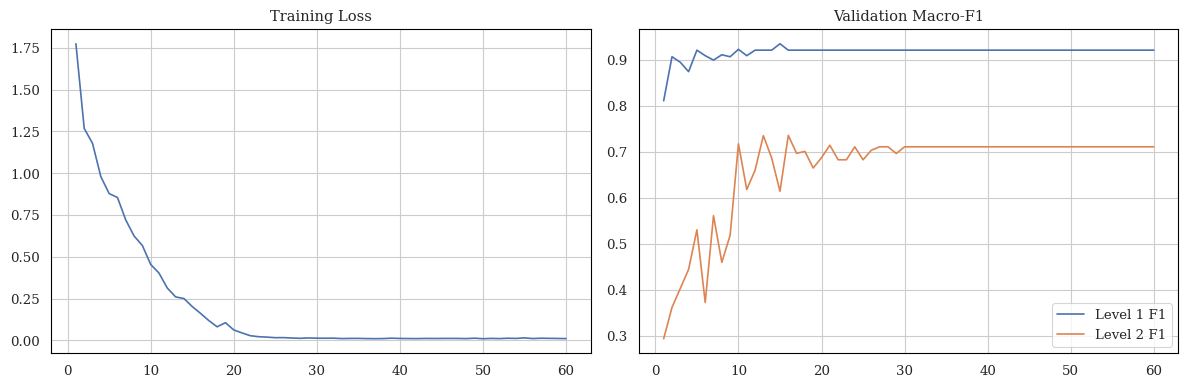

In [ ]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['loss'])
axes[0].set_title('Training Loss')
axes[1].plot(hist_df['epoch'], hist_df['val_f1_l1'], label='Level 1 F1')
axes[1].plot(hist_df['epoch'], hist_df['val_f1_l2'], label='Level 2 F1')
axes[1].legend()
axes[1].set_title('Validation Macro-F1')
plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load('/content/best_model.pt'))
model.eval()

all_l1_preds, all_l1_true, all_l2_preds, all_l2_true = [], [], [], []
with torch.no_grad():
    for x, y1, y2 in val_loader:
        x = x.to(device)
        l1_logits, l2_logits = model(x)
        all_l1_preds.extend(l1_logits.argmax(1).cpu().numpy())
        all_l1_true.extend(y1.numpy())
        all_l2_preds.extend(l2_logits.argmax(1).cpu().numpy())
        all_l2_true.extend(y2.numpy())

print("=== Level 1: Support vs Troll ===")
print(classification_report(all_l1_true, all_l1_preds, target_names=le1.classes_))

print("=== Level 2: Target Identification ===")
print(classification_report(all_l2_true, all_l2_preds, target_names=le2.classes_))

=== Level 1: Support vs Troll ===
                precision    recall  f1-score   support

Support/Praise       0.96      0.82      0.88        28
  Troll/Oppose       0.93      0.99      0.96        69

      accuracy                           0.94        97
     macro avg       0.94      0.90      0.92        97
  weighted avg       0.94      0.94      0.94        97

=== Level 2: Target Identification ===
                             precision    recall  f1-score   support

          Support for party       0.62      0.71      0.67         7
         Support for person       0.94      0.76      0.84        21
 Troll/Oppose Against Party       0.69      0.50      0.58        18
Troll/Oppose Against Person       0.80      0.92      0.85        51

                   accuracy                           0.79        97
                  macro avg       0.76      0.72      0.74        97
               weighted avg       0.80      0.79      0.79        97



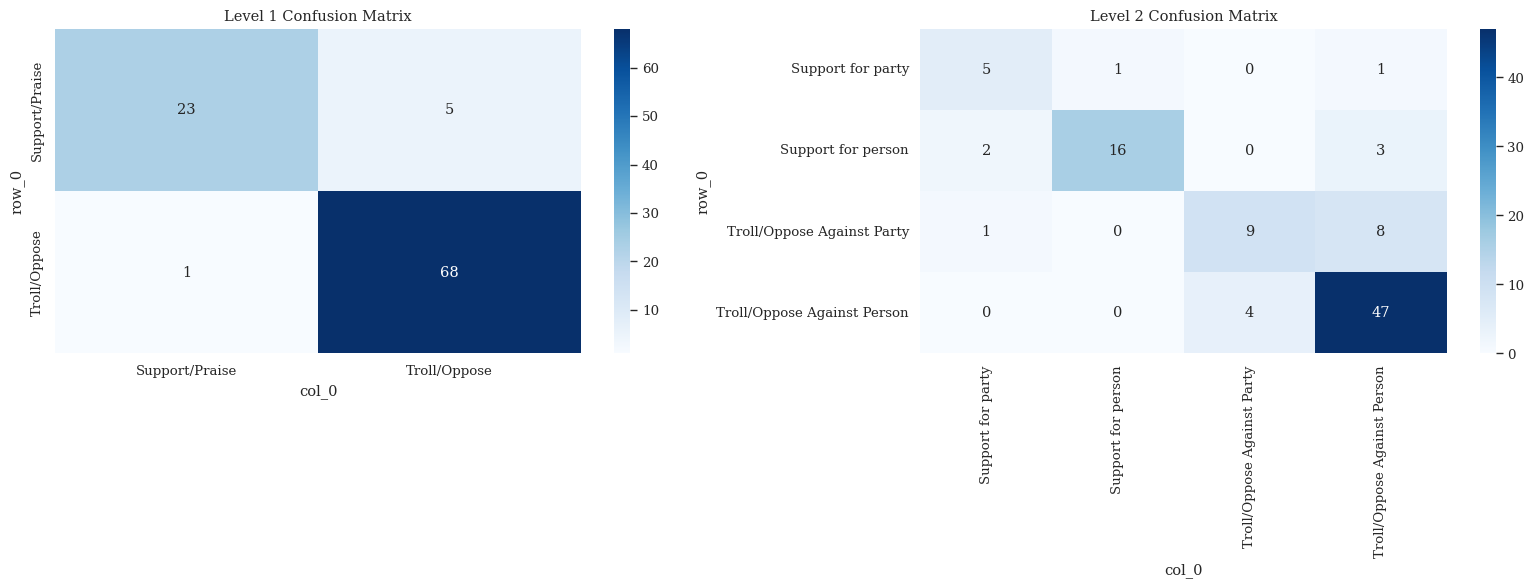

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pd.crosstab(pd.Series(all_l1_true).map(lambda i: le1.classes_[i]),
                        pd.Series(all_l1_preds).map(lambda i: le1.classes_[i])),
            annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Level 1 Confusion Matrix')

sns.heatmap(pd.crosstab(pd.Series(all_l2_true).map(lambda i: le2.classes_[i]),
                        pd.Series(all_l2_preds).map(lambda i: le2.classes_[i])),
            annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Level 2 Confusion Matrix')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# Test Part

In [ ]:
IMAGE_DIR = "/content/drive/MyDrive/CPS Internship/shared task/Test/test_images"
TEST_EXCEL = "/content/drive/MyDrive/CPS Internship/shared task/Test/test-unlabelled.csv"

In [ ]:
test_df = pd.read_csv(TEST_EXCEL)

print("Shape of the dataframe is : ", test_df.shape)
test_df.head()

Shape of the dataframe is :  (244, 2)


,Image_id,Text
0,0,குதிரை வேகத்தில் செயல்படும் அரசே தவிர.. குதிரை...
1,1,“உதனால் அனைத்து நாம் என்ன தீக்குச்சியா?”\nஉதயச...
2,2,வா...போ..ங்கோ...போன்றவை பாசத்தில்‌\n\nபேசுவது....
3,3,என்னிக்கு உங்க மூஞ்சில முழிச்சனோ..\nஇன்னிக்கு ...
4,4,INTERNATIONAL YOGA DAY\n\n ONE YEAR OF CAPTAIN...


In [ ]:
files_in_dir = os.listdir(IMAGE_DIR)
stem_to_file = {}
for fname in files_in_dir:
    stem, ext = os.path.splitext(fname)
    stem_to_file[stem] = fname

def resolve_image_path(image_id):
    stem = str(image_id).zfill(3)   # 0 -> "000", 1 -> "001", etc.
    if stem in stem_to_file:
        return stem_to_file[stem]
    return None

test_df['image_path'] = test_df['Image_id'].apply(resolve_image_path)

test_df.head()

,Image_id,Text,image_path
0,0,குதிரை வேகத்தில் செயல்படும் அரசே தவிர.. குதிரை...,000.jpg
1,1,“உதனால் அனைத்து நாம் என்ன தீக்குச்சியா?”\nஉதயச...,001.jpg
2,2,வா...போ..ங்கோ...போன்றவை பாசத்தில்‌\n\nபேசுவது....,002.jpg
3,3,என்னிக்கு உங்க மூஞ்சில முழிச்சனோ..\nஇன்னிக்கு ...,003.jpg
4,4,INTERNATIONAL YOGA DAY\n\n ONE YEAR OF CAPTAIN...,004.jpg


In [ ]:
test_img_emb   = get_image_embeddings(test_df['image_path'].tolist(), batch_size=32)

test_txt_emb   = get_text_embeddings(test_df['Text'].astype(str).tolist(), batch_size=32)

print(test_img_emb.shape, test_txt_emb.shape)

  0%|          | 0/8 [00:00<?, ?it/s]

(244, 512) (244, 1024)


In [ ]:
test_features   = np.concatenate([test_img_emb, test_txt_emb], axis=1)
print("Fused feature dim:", test_features.shape[1])

Fused feature dim: 1536


In [ ]:
class TestMemeFeatureDataset(Dataset):
    def __init__(self, features):
        self.features = torch.tensor(features, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]

test_ds   = TestMemeFeatureDataset(test_features)

test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False)

In [ ]:
model.load_state_dict(torch.load('/content/best_model.pt'))
model.eval()

all_l1_preds, all_l2_preds = [], []
with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        l1_logits, l2_logits = model(x)
        all_l1_preds.extend(l1_logits.argmax(1).cpu().numpy())
        all_l2_preds.extend(l2_logits.argmax(1).cpu().numpy())

In [ ]:
test_l1_pred = le1.inverse_transform(all_l1_preds)
test_l2_pred = le2.inverse_transform(all_l2_preds)

test_df['Level1'] = test_l1_pred
test_df['Level2'] = test_l2_pred

test_df.head()

,Image_id,Text,image_path,Level1,Level2
0,0,குதிரை வேகத்தில் செயல்படும் அரசே தவிர.. குதிரை...,000.jpg,Support/Praise,Support for person
1,1,“உதனால் அனைத்து நாம் என்ன தீக்குச்சியா?”\nஉதயச...,001.jpg,Support/Praise,Support for person
2,2,வா...போ..ங்கோ...போன்றவை பாசத்தில்‌\n\nபேசுவது....,002.jpg,Troll/Oppose,Troll/Oppose Against Person
3,3,என்னிக்கு உங்க மூஞ்சில முழிச்சனோ..\nஇன்னிக்கு ...,003.jpg,Troll/Oppose,Troll/Oppose Against Person
4,4,INTERNATIONAL YOGA DAY\n\n ONE YEAR OF CAPTAIN...,004.jpg,Troll/Oppose,Troll/Oppose Against Person


In [ ]:
selected_cols = ["Image_id", "Text",  "Level1", "Level2"]

test_df[selected_cols].to_csv("CPSLab1_TamilPoliticalMeme_run1.csv", index=False)